In [40]:
import numpy as np
import emcee 
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm

In [51]:
transient = np.load('transient.npy')
time = transient[:, 0]
flux = transient[:, 1]
errs = transient[:, 2]

N = len(time)

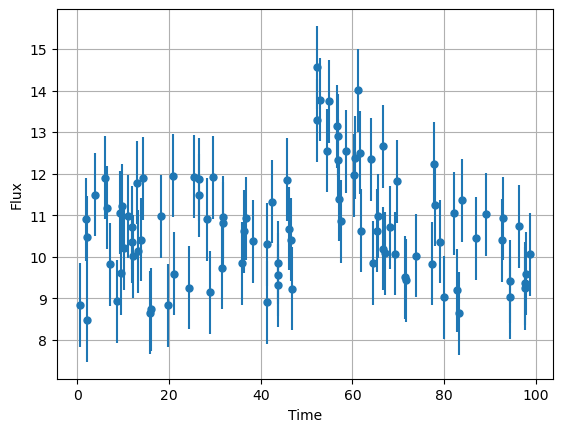

In [3]:
fig, ax = plt.subplots()
plt.errorbar(x=time, y=flux, yerr=errs, fmt='o', markersize=5)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.grid()

In [52]:
def model(t, b, t0, A, alpha):

    y = np.zeros(len(t))
    cond = (t < t0)

    y[cond] += b
    y[~cond] += b + A*np.exp(-alpha*(t[~cond]-t0))
    
    return y

In [46]:
def log_lik(params, times, data, err):
    b, t0, A, logalpha = params 
    alpha = np.exp(logalpha)
    modely = model(times, b, t0, A, alpha)
    
    loglik = -0.5 * np.sum(((data-modely) / err)**2 + np.log(2 * np.pi * err**2))
    return loglik

In [47]:
# all the priors are uniform between these ranges:
# b and A between 0 and 50
# t0 between 0 and 100
# log(alpha) between -5 and 5

def log_prior(params):
    
    b, t0, A, logalpha = params 
    
    condb = (b >= 0) and (b <= 50)
    condA = (A >= 0) and (A <= 50)
    condt = (t0 >= 0) and (t0 <= 100)
    condalph = (logalpha >= -5) and (logalpha <= 5)

    if condb and condA and condt and condalph:
        return np.log(1/50) * 2 + np.log(1/100) + np.log(1/10)

    else: 
        return -np.inf

def log_post(params, times, data, err):
    # posterior = likelihood * prior
    lp = log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
        
    return log_lik(params, times, data, err) + lp

In [53]:
nsteps = 100000
nparam = 4
nwalkers = 9
#burn = we'll see

starting_guesses = np.zeros((nwalkers, nparam))
starting_guesses[:, 0] = np.random.uniform(0, 50, nwalkers)
starting_guesses[:, 1] = np.random.uniform(0, 50, nwalkers)
starting_guesses[:, 2] = np.random.uniform(0, 100, nwalkers)
starting_guesses[:, 3] = np.random.uniform(-5, 5, nwalkers)

sampler = emcee.EnsembleSampler(nwalkers, nparam, log_post, args=[time, flux, errs])
sampler.run_mcmc(starting_guesses, nsteps)

C:\Users\perri\anaconda3\envs\New_env_for_fun\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


State([[10.51960048 51.42304393  3.75206689 -1.99511413]
 [10.36197681 51.71031221  3.86442255 -2.04765624]
 [10.50234204 47.79742985  7.1519223  -1.99771575]
 [10.4952155  47.34757839  7.93710002 -1.89536776]
 [10.45739591 51.68719633  3.42141526 -2.4050011 ]
 [10.26659594 47.166088    4.59900348 -2.32427352]
 [10.34662667 48.06120817  9.35728874 -1.73403825]
 [10.33720856 50.02119314  4.30594383 -2.29870907]
 [10.25896995 49.60108393  5.25402983 -2.18340561]], log_prob=[-157.3680503  -155.66190285 -157.27144384 -156.98806896 -158.30202858
 -157.80790046 -157.31583867 -155.9749375  -155.51327013], blobs=None, random_state=('MT19937', array([3851259153, 3024133523, 2296402453, 3995467212, 1933858796,
        409966745,  649524596, 2813042022, 3033601936, 2724059511,
       2622173725, 3603847403,  432345638, 1741113839,  856584895,
       3966887688,  948513706,  671278958, 1234719777, 3391720751,
       2526392436, 3763713726, 3412260571, 3099395035, 4222781065,
       2630860297, 151

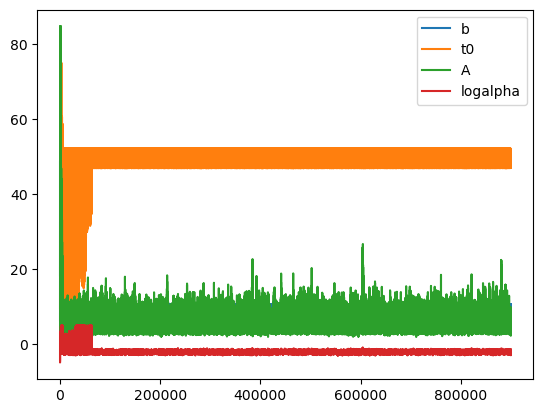

In [58]:
sampler_trace = sampler.get_chain(flat=True)
logprob = sampler.get_log_prob()

fig, ax = plt.subplots()
plt.plot(sampler_trace[:, 0], label='b')
plt.plot(sampler_trace[:, 1], label='t0')
plt.plot(sampler_trace[:, 2], label='A')
plt.plot(sampler_trace[:, 3], label='logalpha')
plt.legend()